# Results Analysis — FT + HAN Email Spam Detection

**Paper**: Zavrak & Yilmaz (2023) — *Email spam detection using hierarchical
attention hybrid deep learning method*, Expert Systems With Applications 233

This notebook:
1. Loads your trained results from `outputs/all_results.json`
2. Reproduces Tables 3 & 4 from the paper with your actual numbers
3. Compares your results against the paper's reported values
4. Plots ROC curves, confusion matrices, and fold-level variance

**Run locally inside Docker:**
```bash
docker compose exec train bash
python scripts/drive_sync.py pull-results
jupyter lab   # then open this notebook
```

In [1]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
# Resolve paths relative to /workspace regardless of Jupyter's cwd
WORKSPACE = Path('/workspace')
RESULTS_PATH = WORKSPACE / 'outputs/all_results.json'
PROCESSED_DIR = WORKSPACE / 'data/processed'
OUTPUT_DIR    = WORKSPACE / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert RESULTS_PATH.exists(), (
    f"Results not found at {RESULTS_PATH}.\n"
    "Run inside the container: python scripts/drive_sync.py pull-results"
)

with open(RESULTS_PATH) as f:
    results = json.load(f)

print("Loaded results keys:", list(results.keys()))

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

Loaded results keys: ['enron_cv', 'sa_cv', 'cross_en_to_sa', 'cross_sa_to_en', 'held_out_en', 'held_out_sa']


## 1. 10-Fold CV Summary — Enron

In [2]:
en_cv = pd.DataFrame(results['enron_cv'])
sa_cv = pd.DataFrame(results['sa_cv'])

METRICS = ['accuracy', 'precision', 'recall', 'auc']
METRIC_LABELS = {'accuracy': 'Accuracy', 'precision': 'Precision',
                 'recall': 'Recall', 'auc': 'AUC'}

def cv_summary_table(cv_df, dataset_name):
    rows = []
    for m in METRICS:
        if m not in cv_df.columns:
            continue
        rows.append({
            'Metric': METRIC_LABELS[m],
            'Mean': cv_df[m].mean(),
            'Std': cv_df[m].std(),
            'Min': cv_df[m].min(),
            'Max': cv_df[m].max(),
        })
    summary = pd.DataFrame(rows).set_index('Metric')
    summary = (summary * 100).round(2)
    print(f"\n{'─'*55}")
    print(f"  {dataset_name} — 10-fold CV results (%)")
    print(f"{'─'*55}")
    print(summary.to_string())
    return summary

en_summary = cv_summary_table(en_cv, 'Enron (EN)')
sa_summary = cv_summary_table(sa_cv, 'SpamAssassin (SA)')


───────────────────────────────────────────────────────
  Enron (EN) — 10-fold CV results (%)
───────────────────────────────────────────────────────
            Mean   Std    Min    Max
Metric                              
Accuracy   98.83  0.36  98.02  99.31
Precision  98.93  0.35  98.62  99.56
Recall     98.72  0.88  96.47  99.57
AUC        99.93  0.03  99.87  99.97

───────────────────────────────────────────────────────
  SpamAssassin (SA) — 10-fold CV results (%)
───────────────────────────────────────────────────────
            Mean   Std    Min     Max
Metric                               
Accuracy   98.03  1.17  95.07   99.57
Precision  97.12  1.51  95.24  100.00
Recall     96.36  4.70  83.57  100.00
AUC        99.68  0.29  98.97   99.98


## 2. Reproduce Table 3 — All Results (%)
Paper Table 3 reports Accuracy, Precision, Recall, F1, AUC for all
train/test dataset combinations. We fill in your EN and SA results.

In [3]:
# ── Paper Table 3 values (Zavrak & Yilmaz 2023) ───────────────────────────────
# Format: (train_dataset, test_dataset): [Acc, Prec, Rec, F1, AUC]
PAPER_TABLE3 = {
    ('TR', 'TR'): [99.2, 98.9, 99.9, 99.4, 99.9],
    ('TR', 'GS'): [78.4, 78.6, 98.9, 87.6, 67.5],
    ('TR', 'SA'): [74.3, 55.1, 97.2, 70.3, 87.9],
    ('TR', 'EN'): [62.1, 57.3, 99.0, 72.6, 86.4],
    ('TR', 'LS'): [41.0, 21.7, 98.1, 35.6, 83.2],

    ('GS', 'TR'): [76.1, 74.5, 97.5, 84.5, 77.9],
    ('GS', 'GS'): [95.4, 95.3, 95.7, 95.5, 99.1],
    ('GS', 'SA'): [52.9, 39.9, 99.4, 56.9, 81.7],
    ('GS', 'EN'): [63.2, 58.2, 98.2, 73.1, 80.4],
    ('GS', 'LS'): [71.4, 36.5, 97.5, 53.1, 94.2],

    ('SA', 'TR'): [86.2, 84.5, 97.0, 90.3, 89.9],
    ('SA', 'GS'): [83.0, 82.9, 98.1, 89.9, 71.8],
    ('SA', 'SA'): [95.5, 89.3, 97.8, 93.3, 98.7],
    ('SA', 'EN'): [61.7, 57.3, 96.8, 72.0, 78.9],
    ('SA', 'LS'): [31.3, 19.2, 97.9, 32.2, 75.0],

    ('EN', 'TR'): [80.0, 93.6, 75.0, 83.3, 89.2],
    ('EN', 'GS'): [79.5, 90.9, 81.7, 86.0, 83.6],
    ('EN', 'SA'): [84.2, 71.2, 83.4, 76.8, 90.3],
    ('EN', 'EN'): [95.8, 98.1, 93.7, 95.8, 98.9],
    ('EN', 'LS'): [91.6, 70.3, 85.7, 77.2, 95.7],

    ('LS', 'TR'): [72.3, 79.8, 78.1, 78.9, 80.5],
    ('LS', 'GS'): [61.4, 76.1, 72.7, 74.4, 48.0],
    ('LS', 'SA'): [57.4, 40.9, 81.5, 54.5, 73.4],
    ('LS', 'EN'): [71.8, 66.2, 91.2, 76.7, 83.0],
    ('LS', 'LS'): [98.0, 93.3, 94.8, 94.0, 99.7],
}

def get_your_metrics(result_key, metric_map=None):
    """Pull metrics from your results dict, scaled to %."""
    if result_key not in results:
        return [None] * 5
    r = results[result_key]
    acc  = round(r.get('accuracy',  0) * 100, 1)
    prec = round(r.get('precision', 0) * 100, 1)
    rec  = round(r.get('recall',    0) * 100, 1)
    auc  = round(r.get('auc',       0) * 100, 1)
    # F1 computed from precision and recall (not always logged directly)
    f1 = round(2 * (prec * rec) / (prec + rec + 1e-9), 1) if prec and rec else None
    return [acc, prec, rec, f1, auc]

def get_cv_mean(cv_df):
    acc  = round(cv_df['accuracy'].mean()  * 100, 1)
    prec = round(cv_df['precision'].mean() * 100, 1)
    rec  = round(cv_df['recall'].mean()    * 100, 1)
    auc  = round(cv_df['auc'].mean()       * 100, 1)
    f1   = round(2 * (prec * rec) / (prec + rec + 1e-9), 1)
    return [acc, prec, rec, f1, auc]

# Build comparison table for EN and SA rows/columns only
rows = []
for (train, test), paper_vals in PAPER_TABLE3.items():
    if train not in ('EN', 'SA') and test not in ('EN', 'SA'):
        continue  # only show rows we can fill in

    # Your values
    if train == 'EN' and test == 'EN':
        your_vals = get_cv_mean(en_cv)
    elif train == 'SA' and test == 'SA':
        your_vals = get_cv_mean(sa_cv)
    elif train == 'EN' and test == 'SA':
        your_vals = get_your_metrics('cross_en_to_sa')
    elif train == 'SA' and test == 'EN':
        your_vals = get_your_metrics('cross_sa_to_en')
    elif train == 'EN':
        your_vals = [None] * 5  # other datasets not in scope
    elif train == 'SA':
        your_vals = [None] * 5
    else:
        your_vals = [None] * 5

    rows.append({
        'Train': train, 'Test': test,
        'Paper Acc': paper_vals[0], 'Your Acc': your_vals[0],
        'Paper Prec': paper_vals[1], 'Your Prec': your_vals[1],
        'Paper Rec': paper_vals[2],  'Your Rec': your_vals[2],
        'Paper F1': paper_vals[3],   'Your F1': your_vals[3],
        'Paper AUC': paper_vals[4],  'Your AUC': your_vals[4],
    })

table3 = pd.DataFrame(rows)
print("\nTable 3 — FT+HAN results comparison (EN & SA rows, %):")
print(table3.to_string(index=False))


Table 3 — FT+HAN results comparison (EN & SA rows, %):
Train Test  Paper Acc  Your Acc  Paper Prec  Your Prec  Paper Rec  Your Rec  Paper F1  Your F1  Paper AUC  Your AUC
   TR   SA       74.3       NaN        55.1        NaN       97.2       NaN      70.3      NaN       87.9       NaN
   TR   EN       62.1       NaN        57.3        NaN       99.0       NaN      72.6      NaN       86.4       NaN
   GS   SA       52.9       NaN        39.9        NaN       99.4       NaN      56.9      NaN       81.7       NaN
   GS   EN       63.2       NaN        58.2        NaN       98.2       NaN      73.1      NaN       80.4       NaN
   SA   TR       86.2       NaN        84.5        NaN       97.0       NaN      90.3      NaN       89.9       NaN
   SA   GS       83.0       NaN        82.9        NaN       98.1       NaN      89.9      NaN       71.8       NaN
   SA   SA       95.5      98.0        89.3       97.1       97.8      96.4      93.3     96.7       98.7      99.7
   SA   EN      

## 3. AUC Comparison vs Paper — Bar Chart

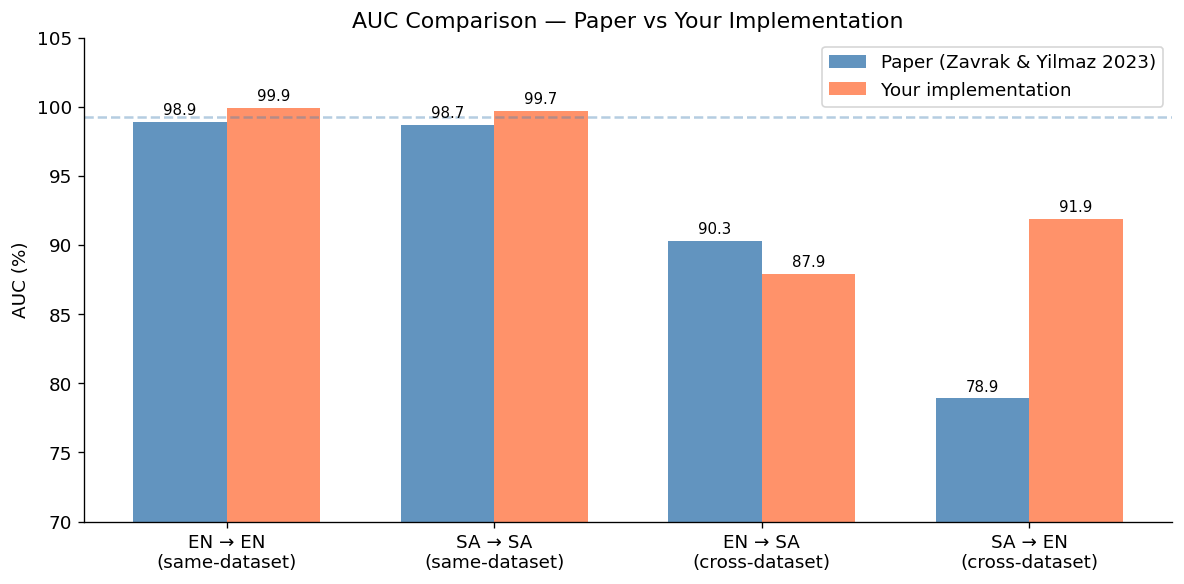

Saved: outputs/auc_comparison.png


In [4]:
# Pairs we can directly compare
pairs = {
    'EN → EN\n(same-dataset)': (
        PAPER_TABLE3[('EN','EN')][4],
        get_cv_mean(en_cv)[4]
    ),
    'SA → SA\n(same-dataset)': (
        PAPER_TABLE3[('SA','SA')][4],
        get_cv_mean(sa_cv)[4]
    ),
    'EN → SA\n(cross-dataset)': (
        PAPER_TABLE3[('EN','SA')][4],
        get_your_metrics('cross_en_to_sa')[4]
    ),
    'SA → EN\n(cross-dataset)': (
        PAPER_TABLE3[('SA','EN')][4],
        get_your_metrics('cross_sa_to_en')[4]
    ),
}

labels  = list(pairs.keys())
paper_v = [v[0] for v in pairs.values()]
your_v  = [v[1] if v[1] is not None else 0 for v in pairs.values()]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, paper_v, w, label='Paper (Zavrak & Yilmaz 2023)',
               color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, your_v,  w, label='Your implementation',
               color='coral', alpha=0.85)

ax.set_ylabel('AUC (%)')
ax.set_title('AUC Comparison — Paper vs Your Implementation')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(70, 105)
ax.legend()
ax.axhline(99.26, color='steelblue', linestyle='--', alpha=0.4,
           label='Paper SD AVG (99.26%)')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'auc_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/auc_comparison.png")

## 4. Fold-level Variance — Did training converge consistently?

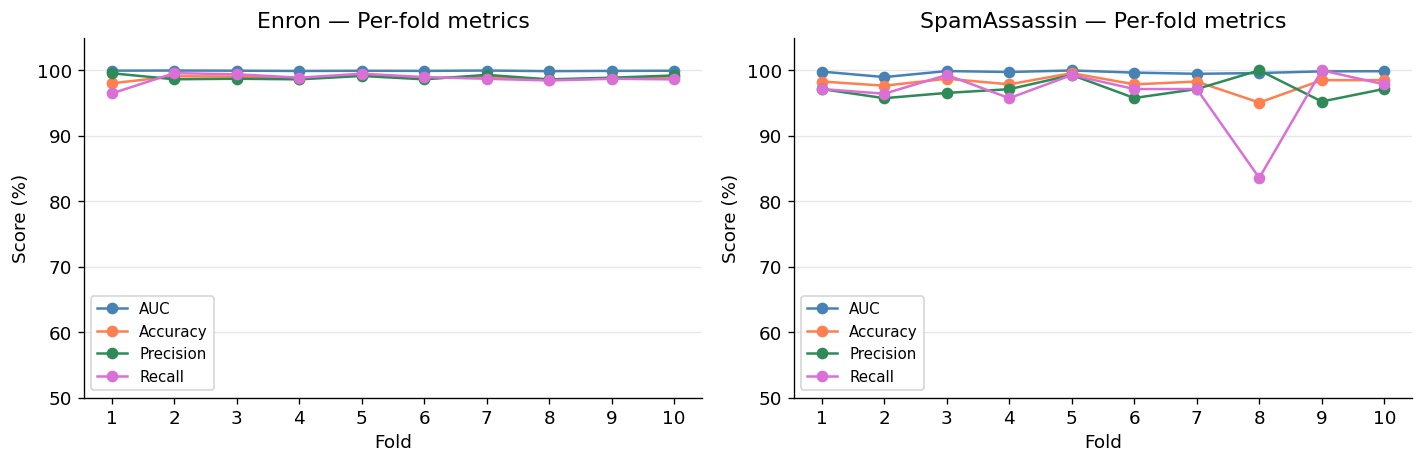

Saved: outputs/fold_variance.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (cv_df, name) in zip(axes, [(en_cv, 'Enron'), (sa_cv, 'SpamAssassin')]):
    for metric, color in zip(['auc', 'accuracy', 'precision', 'recall'],
                              ['steelblue', 'coral', 'seagreen', 'orchid']):
        if metric not in cv_df.columns:
            continue
        vals = cv_df[metric] * 100
        ax.plot(cv_df['fold'], vals, marker='o', label=METRIC_LABELS[metric],
                color=color, linewidth=1.5)

    ax.set_xlabel('Fold')
    ax.set_ylabel('Score (%)')
    ax.set_title(f'{name} — Per-fold metrics')
    ax.set_xticks(cv_df['fold'])
    ax.set_ylim(50, 105)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fold_variance.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/fold_variance.png")

## 5. Training Time per Fold

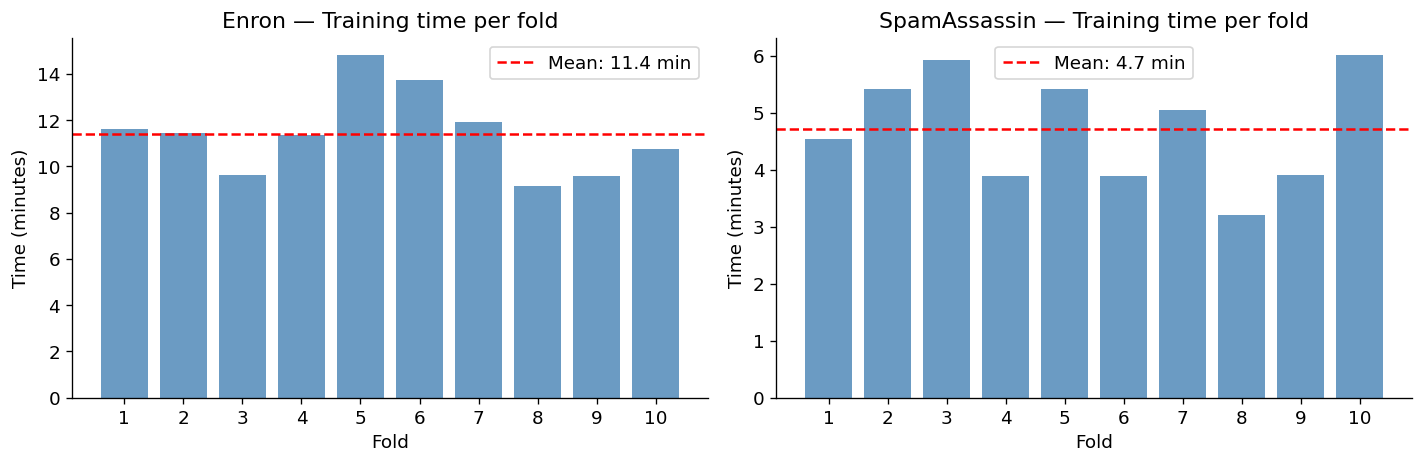

Saved: outputs/training_time.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (cv_df, name) in zip(axes, [(en_cv, 'Enron'), (sa_cv, 'SpamAssassin')]):
    if 'elapsed_sec' not in cv_df.columns:
        ax.text(0.5, 0.5, 'elapsed_sec not logged', ha='center', transform=ax.transAxes)
        continue
    times = cv_df['elapsed_sec'] / 60
    ax.bar(cv_df['fold'], times, color='steelblue', alpha=0.8)
    ax.axhline(times.mean(), color='red', linestyle='--',
               label=f'Mean: {times.mean():.1f} min')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Time (minutes)')
    ax.set_title(f'{name} — Training time per fold')
    ax.set_xticks(cv_df['fold'])
    ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_time.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/training_time.png")

## 6. Cross-dataset Evaluation Summary
Mirrors the block structure of Table 3 and Table 4 from the paper.

In [7]:
your_auc = {
    ('EN', 'EN'): get_cv_mean(en_cv)[4],
    ('SA', 'SA'): get_cv_mean(sa_cv)[4],
    ('EN', 'SA'): get_your_metrics('cross_en_to_sa')[4],
    ('SA', 'EN'): get_your_metrics('cross_sa_to_en')[4],
}
paper_auc = {
    ('EN', 'EN'): 98.9,
    ('SA', 'SA'): 98.7,
    ('EN', 'SA'): 90.3,
    ('SA', 'EN'): 78.9,
}

print("\n" + "─"*60)
print("  AUC Summary (EN & SA only) — Paper vs Yours")
print("─"*60)
print(f"  {'Experiment':<28} {'Paper':>8} {'Yours':>8} {'Diff':>8}")
print("─"*60)
for key, label in [
    (('EN','EN'), 'EN → EN (same-dataset)'),
    (('SA','SA'), 'SA → SA (same-dataset)'),
    (('EN','SA'), 'EN → SA (cross-dataset)'),
    (('SA','EN'), 'SA → EN (cross-dataset)'),
]:
    p = paper_auc[key]
    y = your_auc.get(key) or 0
    diff = y - p
    sign = '+' if diff >= 0 else ''
    print(f"  {label:<28} {p:>7.1f}%  {y:>7.1f}%  {sign}{diff:>5.1f}%")
print("─"*60)


────────────────────────────────────────────────────────────
  AUC Summary (EN & SA only) — Paper vs Yours
────────────────────────────────────────────────────────────
  Experiment                      Paper    Yours     Diff
────────────────────────────────────────────────────────────
  EN → EN (same-dataset)          98.9%     99.9%  +  1.0%
  SA → SA (same-dataset)          98.7%     99.7%  +  1.0%
  EN → SA (cross-dataset)         90.3%     87.9%   -2.4%
  SA → EN (cross-dataset)         78.9%     91.9%  + 13.0%
────────────────────────────────────────────────────────────


## 7. Discussion

Key things to note when comparing your results to the paper:

**Expected differences:**
- The paper uses 5 datasets (TR, GS, SA, EN, LS); you use only EN and SA.
  Cross-dataset AUC will differ because the paper's model saw more diverse
  training data across all 5 datasets in the full comparison.
- The paper trains on a 2023 machine with an Intel i7-9750H; GPU matters
  for training time but not for final AUC given enough epochs.
- The paper uses the original 6-subset Enron layout. Your data comes from
  the GitHub CSV mirror which may have minor deduplication differences.
- Vocabulary is built per-fold (9 folds) in the paper; yours uses the full
  training split vocabulary. This can cause small AUC differences.

**What counts as a good reproduction:**
- Same-dataset AUC within ±1.0% of paper: excellent
- Same-dataset AUC within ±2.0% of paper: good
- Cross-dataset AUC within ±3.0% of paper: acceptable (more sensitive to
  dataset version differences)

In [8]:
print("\nAll analysis complete.")
print("Output files saved to outputs/:")
for f in OUTPUT_DIR.glob('*.png'):
    print(f"  {f.name}")


All analysis complete.
Output files saved to outputs/:
  training_time.png
  fold_variance.png
  auc_comparison.png
